In [16]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

# Demosaicing vs. Direct Fit — Head-to-Head Comparison

Compares localisation precision (σ_xy) and colour precision (σ_colour) for four
fitting-strategy configurations on a Bayer-filtered camera:

| Strategy | Description |
|---|---|
| `STANDARD_DATA` | Direct fit on raw Bayer data, smooth→model→raw-data-weighted refit (current production default — see `SR_Functions.py`) |
| `DEMOSAIC` (bilinear) | Demosaic the puncta ROI with bilinear interpolation (non-variance-aware), then fit each of the resulting R/G/B images independently with a weighted Gaussian fit (weighting only enters here, at the per-channel fit). |
| `DEMOSAIC` (malvar) | As above, using Malvar (2004) demosaicing. |
| `DEMOSAIC` (menon2007) | As above, using Menon (2007) demosaicing. |

For all three `DEMOSAIC` configurations, position (xc, yc) is the photon-weighted mean
of the three channels' fitted positions; total photons = sum of the three channels'
photon counts; per-channel colour = that channel's photon count normalised to the sum.
The demosaicing algorithm is the only thing that differs between the three — set via
`SimulationConfig.demosaic_strategy`. This consolidates the old
`DEMOSAIC`/`DEMOSAIC_FAST`/`DEMOSAIC_IG` variants into one strategy.

Ground truth positions are subtracted internally (`subtractx0y0=True`) so that
σ_xy = std(xc) is comparable across strategies without needing a shared ground-truth file.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import types
import time
import xarray as xr
from pathlib import Path
from scipy.spatial.distance import cdist

import sys
sys.path.append("../../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions
from src.Multicolour_Simulation_Functions import FittingStrategy, CameraParameters, SimulationConfig, FittingResultProcessor
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

# Bare import (not `from src.ImageAnalysisFunctions import ...`) -- see claude/TODO.md's
# note on the dual-import module-identity trap: Multicolour_Simulation_Functions bare-imports
# ImageAnalysisFunctions internally, so importing it the same way here keeps FittingStrategy
# consistent with what MSF uses. Aliased to avoid clashing with the simulation FittingStrategy above.
from ImageAnalysisFunctions import FittingStrategy as IAF_FittingStrategy
import gaussoptfuncs

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()

print("Available fitting strategies:", [s.value for s in FittingStrategy])

Available fitting strategies: ['standard', 'standard_iter', 'standard_data', 'elliptical', 'demosaic', 'demosaic_fast', 'demosaic_ig', 'standard_ig']


## Camera calibration and optical setup

In [18]:
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain     = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset   = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe      = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])  # Bayer channel order: B, G, R

In [19]:
image_size = 14
masks = M_F.get_masks(size_x=image_size, size_y=image_size)

camera_parameters_dict = {
    "gain":     np.full((image_size, image_size), np.median(gain)),
    "offset":   np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise":np.full((image_size, image_size), np.median(readnoise)),
    "rqe":      np.full((image_size, image_size), np.median(rqe)),
    "masks":    masks,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    "mosaic_unit":          M_F.mosaic_unit,
}

validated_camera = CameraParameters.validate_and_create(camera_parameters_dict)
print("Camera parameters validated.")

Camera parameters validated.


In [20]:
# Gaussian pre-smoothing applied before spot detection
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

# Optical path filters (same as Figure 1)
filters = [
    "semrock-di03-r405-488-561-635-t1-25x36",  # dichroic
    "semrock-nf03-405-488-561-635e",            # notch
]

## Simulation configuration

In [21]:
from dataclasses import replace

base_config = SimulationConfig(
    n_bootstrap=10000,
    background_photons=10.0,
    background_colour=[1, 1, 1],
    NA=1.49,
    pixel_size=69,
    cpu_fraction=0.9,
    save_raw_results=True,
    subtractx0y0=True,   # ground truth subtracted before saving — std(xc) = precision
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
    n_unit_cells=7,
)

# Dyes and photon range matching Figure 1
dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)

# Save folder
save_folder = r"/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260320_Demosaic_vs_DirectFit"
os.makedirs(save_folder, exist_ok=True)
print(f"Results will be saved to: {save_folder}")

Results will be saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260320_Demosaic_vs_DirectFit


## Example fits: normal vs. demosaic (single punctum)

Before running the full precision sweep, sanity-check both fitting strategies on one
simulated punctum: `EXAMPLE_DYE` (user-choosable — `"ATTO 488"`/`"ATTO 565"`/`"ATTO 647N"`),
1000 signal photons, 10 background photons/pixel.

- **Direct fit (`STANDARD_DATA`)**: same raw / weights / fit (red X = recovered position)
  / residual / spectrum panels as the real-data `FigureSI_ExampleAnalysisWorkflow.ipynb`.
- **Demosaic fit (`DEMOSAIC`)**: demosaic the punctum into B/G/R images, fit each
  independently (red X = that channel's own recovered position), then the final combined
  spectral fingerprint.

In [22]:
example_fig_savefolder = Path("/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Demosaic_vs_Fit")


In [23]:
EXAMPLE_DYE = "ATTO 565"   # "ATTO 488" | "ATTO 565" | "ATTO 647N"
EXAMPLE_N_PHOTONS = 1000.0
EXAMPLE_BACKGROUND = 10.0

example_fig_savefolder = Path("/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Demosaic_vs_Fit")
example_fig_savefolder.mkdir(parents=True, exist_ok=True)

avg_wl_ex, dpe_ex = S_F.get_pixel_fractions_dye_and_filters(
    [EXAMPLE_DYE], filters, wavelength, pixel_QYs, normalized=False
)
# "Correct" (ground-truth) B/G/R colour fraction for the spectrum bar plots -- the same
# dye_fit_expectation quantity _setup_simulation_parameters computes for the full sweep.
true_colour_ex = np.ravel(dpe_ex) / np.sum(dpe_ex)

x0_ex = y0_ex = image_size * 69 / 2.0
x0y0_ex = {"dye": np.array([[[x0_ex], [y0_ex]]])}
n_photons_ex = {"dye": np.array([EXAMPLE_N_PHOTONS])}

bayer_image_ex, smoothed_image_ex, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict, wavelength, avg_wl_ex, dpe_ex, n_photons_ex, x0y0_ex,
    smoothing_function=smoothing_function, background_photons=EXAMPLE_BACKGROUND,
    background_colour=[1, 1, 1], NA=1.49, pixel_size=69,
)
# gen_camera_image_stack squeezes a batch of 1 down to 2D; restore the frame axis for
# the downstream _prepare_fitting_data/_perform_fitting calls, which index [frame, :, :].
if bayer_image_ex.ndim == 2:
    bayer_image_ex = bayer_image_ex[np.newaxis]
    smoothed_image_ex = smoothed_image_ex[np.newaxis]

print(f"Simulated one {EXAMPLE_DYE} punctum: {EXAMPLE_N_PHOTONS:.0f} photons, "
      f"{EXAMPLE_BACKGROUND:.0f} background photons/pixel")
print("True B/G/R colour fraction:", dict(zip(validated_camera.pixel_order, true_colour_ex)))

Simulated one ATTO 565 punctum: 1000 photons, 10 background photons/pixel
True B/G/R colour fraction: {'B': 0.026076003946837172, 'G': 0.39223774528002298, 'R': 0.58168625077313996}


In [24]:
example_config = replace(base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND)

pe_standard, sm_standard, _ = MSF._prepare_fitting_data(
    bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.STANDARD_DATA, example_config,
)
weights_standard, _ = MSF._compute_error_maps(sm_standard, None, validated_camera)
fit_standard = MSF._perform_fitting(
    FittingStrategy.STANDARD_DATA, pe_standard, sm_standard, weights_standard, None, validated_camera, example_config,
)

xc_std, yc_std = fit_standard["xc"].iloc[0], fit_standard["yc"].iloc[0]
s_x_std, s_y_std = fit_standard["s_x"].iloc[0], fit_standard["s_y"].iloc[0]
A_frac_std = np.array([fit_standard[f"A_{c}"].iloc[0] for c in validated_camera.pixel_order])
bg_frac_std = np.array([fit_standard[f"bg_{c}"].iloc[0] for c in validated_camera.pixel_order])
A_abs_std = A_frac_std * fit_standard["photons"].iloc[0]
bg_abs_std = bg_frac_std * fit_standard["background_photons"].iloc[0]

# Reconstruct the fitted PSF model for the residual panel: Gaussian x Bayer mask,
# using the fractions de-normalised back to absolute (photon-like) units by the fit's
# own 'photons'/'background_photons' totals -- same convention as the real-data
# FigureSI_ExampleAnalysisWorkflow.ipynb notebook.
x_arr = np.arange(image_size, dtype=np.float32)
gauss2d_std = np.zeros((image_size, image_size), dtype=np.float32)
gauss2d_std = gaussoptfuncs.gaussian_unscaled_model(gauss2d_std, x_arr, image_size, xc_std, yc_std, s_x_std, s_y_std)

model_standard = np.zeros((image_size, image_size), dtype=np.float32)
for i, c in enumerate(validated_camera.pixel_order):
    m = validated_camera.masks[c]
    model_standard[m] = A_abs_std[i] * gauss2d_std[m] + bg_abs_std[i]

residual_standard = pe_standard[0] - model_standard

In [ ]:
channel_colours = ["#5555ff", "#53b03b", "#ff2a2a"]  # B, G, R -- matches Ternary_Plot_SingleMolecules.ipynb

fig, axs = plotter.two_column_plot(ncols=5, width_ratios=np.ones(5), width=8.5, height=1.9)
raw_vmin, raw_vmax = np.percentile(pe_standard[0], [1, 99])

axs[0], _ = plotter.image_plot(axs[0], pe_standard[0], vmin=raw_vmin, vmax=raw_vmax, origin="upper")
axs[0].set_title("Raw", fontsize=8)

axs[1].imshow(weights_standard[0], cmap="gray", origin="upper")
axs[1].set_xticks([]); axs[1].set_yticks([])
axs[1].set_title("Weights", fontsize=8)

axs[2], _ = plotter.image_plot(axs[2], model_standard, vmin=raw_vmin, vmax=raw_vmax, origin="upper")
axs[2].plot(xc_std, yc_std, "rx", markersize=8, markeredgewidth=2)
axs[2].set_title("Fit", fontsize=8)

rmax = np.max(np.abs(residual_standard))
axs[3].imshow(residual_standard, cmap="RdBu_r", vmin=-rmax, vmax=rmax, origin="upper")
axs[3].set_xticks([]); axs[3].set_yticks([])
axs[3].set_title("Residual", fontsize=8)

axs[4].bar(np.arange(3), A_frac_std, color=channel_colours)
axs[4].hlines(
    true_colour_ex, xmin=np.arange(3) - 0.4, xmax=np.arange(3) + 0.4,
    colors="k", linestyles=":", linewidth=1.5, label="true",
)
axs[4].set_ylim([0, 1]); axs[4].set_xticks([]); axs[4].set_yticks([0, 1]); axs[4].grid(False)
axs[4].set_title("Spectrum", fontsize=8)

fig.suptitle(f"Direct fit (STANDARD_DATA) — {EXAMPLE_DYE}", fontsize=9, y=1.05)
plotter.save_or_show(fig, save_path=str(example_fig_savefolder / "example_fit_standard_data.svg"), show=True)

### Demosaic fit — R/G/B images and per-channel positions

Demosaic the same punctum (non-variance-aware bilinear demosaic), then fit each of the
resulting B/G/R images independently (this is where weighting enters). Each panel below
shows that channel's demosaiced image with its own independently-fitted position marked;
the final panel shows the combined spectral fingerprint (photon-weighted position,
photon-normalised colour -- computed exactly as `FittingStrategy.DEMOSAIC` does in
production).

In [26]:
demosaic_example_config = replace(
    base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="malvar",
)

pe_demosaic, sm_demosaic, _ = MSF._prepare_fitting_data(
    bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.DEMOSAIC, demosaic_example_config,
)
weights_demosaic, _ = MSF._compute_error_maps(sm_demosaic, None, validated_camera)

# Fit each demosaiced channel independently (mirrors _fit_demosaic's internals exactly),
# but keep the raw per-channel result so each channel's own fitted position can be plotted
# (the production path only keeps the final photon-weighted/normalised combination).
puncta_ch   = [pe_demosaic[c] for c in range(3)]
smoothed_ch = [sm_demosaic[c] for c in range(3)]
weights_ch  = [weights_demosaic[c] for c in range(3)]
coords_ch   = [(0, 0)] * 3
planes_ch   = [0, 1, 2]

raw_channel_fits, _ = MSF.image_analysis.fit_puncta_parallel_method(
    puncta_ch, smoothed_ch, weights_ch, coords_ch, planes_ch, IAF_FittingStrategy.NOCOLOUR,
)
raw_channel_fits = pd.DataFrame(
    raw_channel_fits, columns=["xc", "yc", "s_x", "s_y", "b", "A", "chi_sqr", "frame"]
).sort_values(by="frame").reset_index(drop=True)
# planes_ch == [0,1,2] matches puncta_ch == [B,G,R] (validated_camera.pixel_order order),
# so after sorting by frame, row i corresponds directly to pixel_order[i].

# Final combined result: photon-weighted position, photon-normalised colour fractions
# (same FittingResultProcessor.fit_averager the production DEMOSAIC strategy uses).
combined_demosaic = FittingResultProcessor.fit_averager(raw_channel_fits, n_bootstrap=1)
spectrum_demosaic = np.array(
    [combined_demosaic[f"A_{c}"].iloc[0] for c in validated_camera.pixel_order]
)

# Per-channel reconstructed model (single-channel Gaussian, no Bayer mask -- each
# channel was fit independently with NOCOLOUR) for the "fit" row of the figure below.
model_channel_fits = []
for row in raw_channel_fits.itertuples():
    gauss2d_ch = np.zeros((image_size, image_size), dtype=np.float32)
    gauss2d_ch = gaussoptfuncs.gaussian_unscaled_model(
        gauss2d_ch, x_arr, image_size, row.xc, row.yc, row.s_x, row.s_y
    )
    model_channel_fits.append(row.A * gauss2d_ch + row.b)

for c, row in zip(validated_camera.pixel_order, raw_channel_fits.itertuples()):
    print(f"{c}: xc={row.xc:.2f} yc={row.yc:.2f} A={row.A:.1f} chi_sqr={row.chi_sqr:.2f}")
print(f"Combined position (photon-weighted): "
      f"xc={combined_demosaic['xc'].iloc[0]:.2f} yc={combined_demosaic['yc'].iloc[0]:.2f}")
print("Combined spectrum:", dict(zip(validated_camera.pixel_order, spectrum_demosaic)))

B: xc=6.51 yc=6.55 A=84.8 chi_sqr=1.12                                                                                                                                                                                                       ?, ?it/s]
G: xc=7.05 yc=6.86 A=432.4 chi_sqr=0.87
R: xc=7.23 yc=7.17 A=714.8 chi_sqr=0.90
Combined position (photon-weighted): xc=7.12 yc=7.02
Combined spectrum: {'B': 0.068814858794212341, 'G': 0.35096782445907593, 'R': 0.58021730184555054}


In [ ]:
fig2, axs2 = plotter.two_column_plot(nrows=2, ncols=5, width_ratios=np.ones(5), height_ratios=[1, 1], width=8.5, height=3.6)

raw_vmin_d, raw_vmax_d = np.percentile(pe_standard[0], [1, 99])

# Column 0: raw data, identical in both rows.
for row in (0, 1):
    axs2[row, 0], _ = plotter.image_plot(axs2[row, 0], pe_standard[0], vmin=raw_vmin_d, vmax=raw_vmax_d, origin="upper")
axs2[0, 0].set_title("Raw", fontsize=8)
axs2[1, 0].set_title("Raw", fontsize=8)

# Columns 1-3: top row = demosaiced B/G/R images; bottom row = each channel's own
# reconstructed fit (single-channel Gaussian model, red X = that channel's fitted position).
cmaps = ['Blues', 'Greens', 'Reds']
for i, c in enumerate(validated_camera.pixel_order):
    vmin_c, vmax_c = np.percentile(pe_demosaic[i], [1, 99])

    axs2[0, i + 1], _ = plotter.image_plot(axs2[0, i + 1], pe_demosaic[i], vmin=vmin_c, vmax=vmax_c, origin="upper",
                                          cmap=cmaps[i])
    axs2[0, i + 1].set_title(f"Demosaic {c}", fontsize=8)

    axs2[1, i + 1], _ = plotter.image_plot(axs2[1, i + 1], model_channel_fits[i], vmin=vmin_c, vmax=vmax_c, origin="upper",
                                          cmap=cmaps[i])
    axs2[1, i + 1].plot(
        raw_channel_fits["xc"].iloc[i], raw_channel_fits["yc"].iloc[i],
        "rx", markersize=8, markeredgewidth=2,
    )
    axs2[1, i + 1].set_title(f"Fit {c}", fontsize=8)

# Column 4: spectral fingerprint, identical in both rows.
for row in (0, 1):
    axs2[row, 4].bar(np.arange(3), spectrum_demosaic, color=channel_colours)
    axs2[row, 4].hlines(
        true_colour_ex, xmin=np.arange(3) - 0.4, xmax=np.arange(3) + 0.4,
        colors="k", linestyles=":", linewidth=1.5, label="true",
    )
    axs2[row, 4].set_ylim([0, 1]); axs2[row, 4].set_xticks([]); axs2[row, 4].set_yticks([0, 1]); axs2[row, 4].grid(False)
    axs2[row, 4].set_title("Spectrum", fontsize=8)

plotter.save_or_show(fig2, save_path=str(example_fig_savefolder / "example_fit_demosaic_malvar.svg"), show=True)

### Timing: direct fit vs. demosaic fit (single punctum)

Wall-clock cost of fitting the one punctum above, direct (`STANDARD_DATA`) vs. demosaic.
Uses the serial `fit_puncta_method` rather than `fit_puncta_parallel_method` -- the
parallel wrapper spins up a fresh `ProcessPoolExecutor` on every call, which massively
dominates (and is not representative of) the cost of fitting a single punctum; the serial
call isolates the actual per-punctum fit cost (`_prepare_fitting_data` + weights + fit).

In [30]:
masks_3d = np.dstack([validated_camera.masks[c] for c in validated_camera.pixel_order])
MSF.image_analysis.processors[IAF_FittingStrategy.STANDARD_DATA].readnoise = float(np.median(validated_camera.readnoise))


def time_standard_once():
    t0 = time.perf_counter()
    pe_s, sm_s, _ = MSF._prepare_fitting_data(
        bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.STANDARD_DATA, example_config,
    )
    w_s, _ = MSF._compute_error_maps(sm_s, None, validated_camera)
    MSF.image_analysis.fit_puncta_method(
        [pe_s[0]], [sm_s[0]], [w_s[0]], [(0, 0)], [0], IAF_FittingStrategy.STANDARD_DATA, masks=[masks_3d],
    )
    return time.perf_counter() - t0


def time_demosaic_once(demosaic_config):
    t0 = time.perf_counter()
    pe_d, sm_d, _ = MSF._prepare_fitting_data(
        bayer_image_ex, smoothed_image_ex, validated_camera, FittingStrategy.DEMOSAIC, demosaic_config,
    )
    w_d, _ = MSF._compute_error_maps(sm_d, None, validated_camera)
    fits, _ = MSF.image_analysis.fit_puncta_method(
        [pe_d[c] for c in range(3)], [sm_d[c] for c in range(3)], [w_d[c] for c in range(3)],
        [(0, 0)] * 3, [0, 1, 2], IAF_FittingStrategy.NOCOLOUR,
    )
    fits_df = pd.DataFrame(
        fits, columns=["xc", "yc", "s_x", "s_y", "b", "A", "chi_sqr", "frame"]
    ).sort_values(by="frame").reset_index(drop=True)
    FittingResultProcessor.fit_averager(fits_df, n_bootstrap=1)
    return time.perf_counter() - t0

demosaic_config_bilinear = replace(
    base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="bilinear",
)
demosaic_config_malvar = replace(
    base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="malvar",
)
demosaic_config_menon = replace(
    base_config, n_bootstrap=1, background_photons=EXAMPLE_BACKGROUND, demosaic_strategy="menon2007",
)


# Warm-up (numba JIT compilation etc.) -- excluded from the timed measurements.
time_standard_once()
time_demosaic_once(demosaic_config_bilinear)
time_demosaic_once(demosaic_config_malvar)
time_demosaic_once(demosaic_config_menon)

N_TIMING_REPEATS = 10000
standard_times = np.array([time_standard_once() for _ in range(N_TIMING_REPEATS)])
demosaic_times_bilinear = np.array([time_demosaic_once(demosaic_config_bilinear) for _ in range(N_TIMING_REPEATS)])
demosaic_times_malvar = np.array([time_demosaic_once(demosaic_config_malvar) for _ in range(N_TIMING_REPEATS)])
demosaic_times_menon = np.array([time_demosaic_once(demosaic_config_menon) for _ in range(N_TIMING_REPEATS)])

print(f"STANDARD_DATA (direct fit), N={N_TIMING_REPEATS}: "
      f"{standard_times.mean()*1000:.3f} +/- {standard_times.std()*1000:.3f} ms")
print(f"BILINEAR DEMOSAIC , N={N_TIMING_REPEATS}: "
      f"{demosaic_times_bilinear.mean()*1000:.3f} +/- {demosaic_times_bilinear.std()*1000:.3f} ms")
print(f"MALVAR DEMOSAIC , N={N_TIMING_REPEATS}: "
      f"{demosaic_times_malvar.mean()*1000:.3f} +/- {demosaic_times_malvar.std()*1000:.3f} ms")
print(f"MENON DEMOSAIC , N={N_TIMING_REPEATS}: "
      f"{demosaic_times_menon.mean()*1000:.3f} +/- {demosaic_times_menon.std()*1000:.3f} ms")

STANDARD_DATA (direct fit), N=10000: 0.465 +/- 0.032 ms
BILINEAR DEMOSAIC , N=10000: 1.468 +/- 0.115 ms
MALVAR DEMOSAIC , N=10000: 1.542 +/- 0.094 ms
MENON DEMOSAIC , N=10000: 2.287 +/- 0.081 ms


INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Demosaic_vs_Fit/example_fit_timing.svg


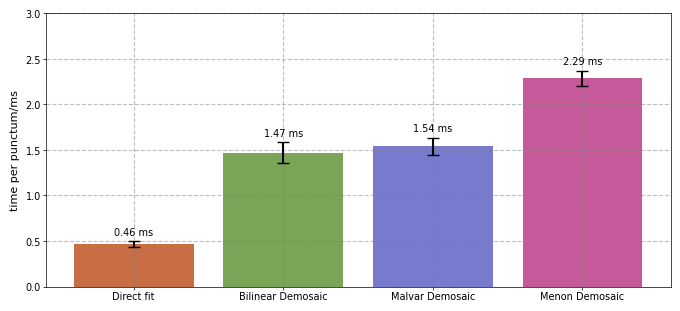

In [40]:
fig3, ax3 = plotter.two_column_plot(ncols=1)

timing_labels = ["Direct fit", "Bilinear Demosaic", "Malvar Demosaic", "Menon Demosaic"]
timing_means_ms = [standard_times.mean() * 1000, demosaic_times_bilinear.mean() * 1000, demosaic_times_malvar.mean() * 1000, demosaic_times_menon.mean() * 1000]
timing_stds_ms = [standard_times.std() * 1000, demosaic_times_bilinear.std() * 1000, demosaic_times_malvar.std() * 1000, demosaic_times_menon.std() * 1000]
ax3.bar(
    timing_labels, timing_means_ms, yerr=timing_stds_ms, capsize=4,
    color=["#c96d44",
"#7aa456",
"#777acd",
"#c65999"],
)
ax3.set_ylabel("time per punctum/ms")
ax3.grid(True, ls='--', alpha=0.5, color='gray')

for i, (mean_ms, std_ms) in enumerate(zip(timing_means_ms, timing_stds_ms)):
    ax3.text(i, mean_ms + std_ms + 0.02 * max(timing_means_ms), f"{mean_ms:.2f} ms",
              ha="center", va="bottom", fontsize=7)

ax3.set_ylim([0, 3])
plotter.save_or_show(fig3, save_path=str(example_fig_savefolder / "example_fit_timing.svg"), show=True)

## Run simulations

Four strategy configurations × three dyes.  
Each configuration uses a distinct `starting_flag` so files do not collide.  
Set `overwrite=False` to resume an interrupted run.

In [6]:
runs = [
    (FittingStrategy.STANDARD_DATA, "standard_data_", base_config),
    (FittingStrategy.DEMOSAIC, "demosaic_bilinear_", replace(base_config, demosaic_strategy="bilinear")),
    (FittingStrategy.DEMOSAIC, "demosaic_malvar_", replace(base_config, demosaic_strategy="malvar")),
    (FittingStrategy.DEMOSAIC, "demosaic_menon2007_", replace(base_config, demosaic_strategy="menon2007")),
]


In [ ]:
camera_params_dict = validated_camera.__dict__.copy()

for strategy, flag, cfg in runs:
    for dye in dyes:
        label = f"{strategy.value} [{cfg.demosaic_strategy}]" if strategy == FittingStrategy.DEMOSAIC else strategy.value
        print(f"Running {label} / {dye} ...")
        try:
            MSF.test_simulation_method(
                dye=dye,
                filters=filters,
                wavelength=wavelength,
                camera_parameters=camera_params_dict,
                save_folder=save_folder,
                n_photon_space=n_photon_space,
                smoothing_function=smoothing_function,
                strategy=strategy,
                starting_flag=flag,
                config=cfg,
                overwrite=False,
            )
            print(f"  Done: {label} / {dye}")
        except Exception as e:
            print(f"  FAILED {label} / {dye}: {e}")

print("All simulations complete.")


Running standard_data / ATTO 488 ...


## Load results and compute precision metrics

Because `subtractx0y0=True`, the saved `xc` and `yc` columns are already
*(fitted − truth)*, so:

$$\sigma_{xy} = \sqrt{\frac{\sigma_x^2 + \sigma_y^2}{2}} \times 69\,\text{nm}$$

Colour precision is the standard deviation of the Euclidean distance from each
fitted $(A_B, A_G, A_R)$ point to the true colour vector.

In [8]:
strategy_labels = ["Direct fit (STANDARD_DATA)", "Demosaic (bilinear)", "Demosaic (malvar)", "Demosaic (menon2007)"]
strategy_flags  = ["standard_data_", "demosaic_bilinear_", "demosaic_malvar_", "demosaic_menon2007_"]
parameters      = ["xy", "colour", "B", "G", "R", "chi_mean", "chi_median", "chi_std"]

all_files = os.listdir(save_folder)

Overall_XR = xr.DataArray(
    data=np.full([len(strategy_labels), len(dyes), len(n_photon_space), len(parameters)], np.nan),
    coords=[strategy_labels, dyes, n_photon_space, parameters],
    dims=["Strategy", "Dye", "Photon", "Metric"],
)

for i, (label, flag) in enumerate(zip(strategy_labels, strategy_flags)):
    # Use flag + "LM_method" as the discriminating prefix so that "standard_"
    # does not accidentally match "standard_data_LM_method_..." files (and each
    # "demosaic_<algorithm>_" flag doesn't match another algorithm's files, or a
    # stray "demosaic_fast_"/"demosaic_ig_" file from an old run).
    prefix = flag + "LM_method"
    flag_files = [x for x in all_files if x.startswith(prefix)]
    for j, dye in enumerate(dyes):
        dyestr = dye.replace("/", "-")
        raw_files = [
            os.path.join(save_folder, x)
            for x in flag_files
            if dyestr in x and "rawresults" in x
        ]
        param_files = [
            os.path.join(save_folder, x)
            for x in flag_files
            if dyestr in x and "input_parameters" in x
        ]
        if not raw_files or not param_files:
            print(f"Missing files for {label} / {dye} — skipping.")
            continue

        true_bgr = pd.read_csv(param_files[0]).to_numpy()[0][-3:]
        true_bgr = true_bgr / np.sum(true_bgr)
        true_colour = np.expand_dims(true_bgr, 0)

        results_all = pd.read_hdf(raw_files[0])

        for k, photonval in enumerate(n_photon_space):
            results = results_all[results_all["photon_level"] == k]
            if len(results) == 0:
                continue

            filt = ~(
                (results["s_x"] < 0)
                | (results["s_y"] < 0)
 #               | (results["xc"].abs() > 14)
 #               | (results["yc"].abs() > 14)
 #               | (results["chi_sqr"] > 10)
            )

            xc = results["xc"].to_numpy()[filt]
            yc = results["yc"].to_numpy()[filt]
            chi_sqr = results["chi_sqr"].to_numpy()[filt]

            sigma_xy = np.sqrt((np.nanstd(xc)**2 + np.nanstd(yc)**2) / 2) * 69

            colour = np.vstack([
                results["A_B"].to_numpy()[filt],
                results["A_G"].to_numpy()[filt],
                results["A_R"].to_numpy()[filt],
            ]).T
            colour_dist = cdist(colour, true_colour).ravel()
            B_dist = np.sqrt(np.square(colour[:, 0] - true_colour[:, 0]))
            G_dist = np.sqrt(np.square(colour[:, 1] - true_colour[:, 1]))
            R_dist = np.sqrt(np.square(colour[:, 2] - true_colour[:, 2]))

            Overall_XR[i, j, k, 0] = sigma_xy
            Overall_XR[i, j, k, 1] = np.nanstd(colour_dist)
            Overall_XR[i, j, k, 2] = np.nanstd(B_dist)
            Overall_XR[i, j, k, 3] = np.nanstd(G_dist)
            Overall_XR[i, j, k, 4] = np.nanstd(R_dist)
            Overall_XR[i, j, k, 5] = np.nanmean(chi_sqr)
            Overall_XR[i, j, k, 6] = np.nanmedian(chi_sqr)
            Overall_XR[i, j, k, 7] = np.nanstd(chi_sqr)
            

print("Results loaded.")
Overall_XR.to_netcdf(os.path.join(save_folder, "Demosaic_vs_DirectFit_STDEV.nc"))
print("Saved to Demosaic_vs_DirectFit_STDEV.nc")

Results loaded.
Saved to Demosaic_vs_DirectFit_STDEV.nc


In [41]:
# (Optional) reload without re-running the simulation
Overall_XR = xr.load_dataarray(os.path.join(save_folder, "Demosaic_vs_DirectFit_STDEV.nc"))

## Plot — dye-averaged precision vs photon count

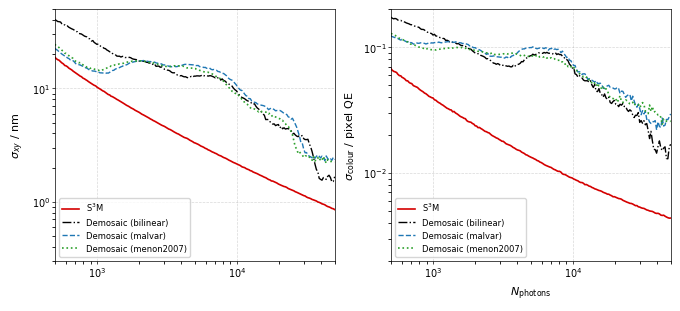

In [47]:
# Colours and line styles for each strategy
plot_styles = [
    {"color": "#d40000", "linestyle": "-",  "linewidth": 1.2},   # Direct fit
    {"color": "black",   "linestyle": "-.", "linewidth": 1.0},   # Demosaic (bilinear)
    {"color": "#1f77b4", "linestyle": "--", "linewidth": 1.0},   # Demosaic (malvar)
    {"color": "#2ca02c", "linestyle": ":",  "linewidth": 1.2},   # Demosaic (menon2007)
]

strategy_labels = ["S$^3$M", "Demosaic (bilinear)", "Demosaic (malvar)", "Demosaic (menon2007)"]

fig, axs = plotter.two_column_plot(ncols=2, width_ratios=np.ones(2))

for i, (label, style) in enumerate(zip(strategy_labels, plot_styles)):
    mean_xy     = np.nanmean(Overall_XR[i, :, :, 0], axis=0)
    mean_colour = np.nanmean(Overall_XR[i, :, :, 1], axis=0)

    axs[0] = plotter.line_plot(
        axs[0], n_photon_space, mean_xy,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{xy}$ / nm",
        **style,
    )
    axs[1] = plotter.line_plot(
        axs[1], n_photon_space, mean_colour,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{\mathrm{colour}}$ / pixel QE",
        **style,
    )

for ax in axs:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([500, 50000])

axs[0].set_ylim([0.3, 50])
axs[0].set_xlabel("")
axs[1].set_ylim([2e-3, 0.2])
axs[0].legend(loc="best", fontsize=6)

fig_savefolder = "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Demosaic_vs_Fit"
os.makedirs(fig_savefolder, exist_ok=True)
plt.savefig(os.path.join(fig_savefolder, "Demosaic_vs_DirectFit.svg"), dpi=600, format="svg")
plt.show()

## Ratio plot — demosaic relative to direct fit

Values > 1 mean the demosaic strategy is worse (larger std); values < 1 mean it is better.

In [ ]:
fig, axs = plotter.one_column_plot(npanels=2, height=3.1909449, ratios=[1, 1], width=3.2535433)

ref_xy     = np.nanmean(Overall_XR[0, :, :, 0], axis=0)  # STANDARD
ref_colour = np.nanmean(Overall_XR[0, :, :, 1], axis=0)

for i, (label, style) in enumerate(zip(strategy_labels[1:], plot_styles[1:]), start=1):
    mean_xy     = np.nanmean(Overall_XR[i, :, :, 0], axis=0)
    mean_colour = np.nanmean(Overall_XR[i, :, :, 1], axis=0)

    axs[0] = plotter.line_plot(
        axs[0], n_photon_space, mean_xy / ref_xy,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{xy}$ / $\sigma_{xy}^{\mathrm{direct}}$",
        **style,
    )
    axs[1] = plotter.line_plot(
        axs[1], n_photon_space, mean_colour / ref_colour,
        label=label,
        xlabel=r"$N_{\mathrm{photons}}$",
        ylabel=r"$\sigma_{\mathrm{colour}}$ / $\sigma_{\mathrm{colour}}^{\mathrm{direct}}$",
        **style,
    )

for ax in axs:
    ax.set_xscale("log")
    ax.set_xlim([500, 50000])
    ax.axhline(1.0, color="#d40000", lw=0.8, ls="-", label="Direct fit (reference)")

axs[0].set_xlabel("")
axs[0].legend(loc="best", fontsize=6)

plt.savefig(os.path.join(fig_savefolder, "Demosaic_vs_DirectFit_Ratio.svg"), dpi=600, format="svg")
plt.show()